In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [19]:
dataset.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

# Data Processing

In [23]:
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
dataset["Gender"]= le.fit_transform(dataset["Gender"])
dataset



,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0
...,...,...,...,...,...
395,15691863,0,46,41000,1
396,15706071,1,51,23000,1
397,15654296,0,50,20000,1
398,15755018,1,36,33000,0


# Dependent y and Independent x}

In [26]:
x = dataset[["Gender","Age","EstimatedSalary"]]
x
y = dataset[["Purchased"]]
y

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


# model selection

In [ ]:
model 

# Select Features (X) and Target (y)

In [3]:
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

# Split Dataset into Training and Testing Set

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [6]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [7]:
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [8]:
y_pred = classifier.predict(X_test)

In [9]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[65  3]
 [ 8 24]]


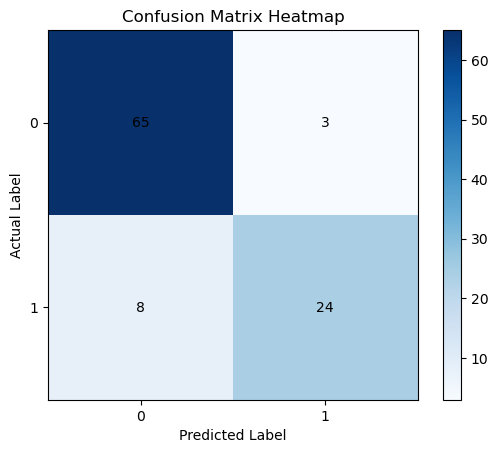

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm, cmap="Blues")   

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [10]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("True Positive (TP):", TP)
print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)

True Positive (TP): 24
True Negative (TN): 65
False Positive (FP): 3
False Negative (FN): 8


In [11]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy:", accuracy)

Accuracy: 0.89


In [12]:
error_rate = 1 - accuracy
print("Error Rate:", error_rate)

Error Rate: 0.10999999999999999


In [13]:
precision = TP / (TP + FP)
print("Precision:", precision)

Precision: 0.8888888888888888


In [14]:
recall = TP / (TP + FN)
print("Recall:", recall)

Recall: 0.75


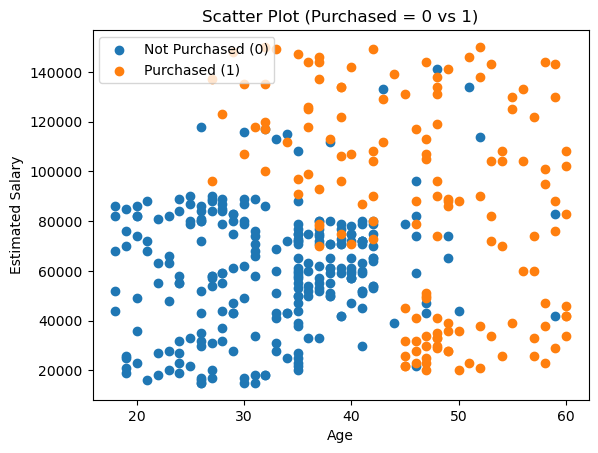

''

In [32]:
X = dataset[["Age", "EstimatedSalary"]].values
y = dataset["Purchased"].values

plt.figure()

plt.scatter(X[y == 0, 0], X[y == 0, 1])

plt.scatter(X[y == 1, 0], X[y == 1, 1])

plt.title("Scatter Plot (Purchased = 0 vs 1)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")

plt.legend(["Not Purchased (0)", "Purchased (1)"])

plt.show()
""